In [112]:
from bs4 import BeautifulSoup as bs
url = "https://www.basketball-reference.com/leagues/NBA_2024_totals.html"

In [113]:
from urllib.request import Request, urlopen
headers = {'User-Agent': 'Mozilla/5.0'}
req = Request(url, headers=headers)
html = urlopen(req).read()

In [114]:
soup = bs(html, 'html.parser')

In [115]:
player_table = soup.find('table')

In [116]:
player_table = soup.find('table', id='totals_stats')
thead = player_table.find('thead')
column_headers = [th.get_text() for th in thead.find_all('th')]
print(column_headers)

['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Trp-Dbl', 'Awards']


In [117]:
print(soup.prettify())

Output hidden; open in https://colab.research.google.com to view.

In [118]:
url = "https://www.basketball-reference.com/leagues/NBA_2024_totals.html"
req = Request(url, headers=headers)
html = urlopen(req).read()
soup = bs(html, 'html.parser')
player_table = soup.find('table')
thead = player_table.find('thead')
column_headers = [th.get_text() for th in thead.find_all('th')]
print(column_headers)

['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Trp-Dbl', 'Awards']


In [119]:
tbody = player_table.find('tbody')
rows = tbody.find_all('tr')
print(f"Found {len(rows)} rows in the table body.")

Found 736 rows in the table body.


In [120]:
player_data = []
for row in rows:
    player_info = {}
    player_name_tag = row.find('th', {'data-stat': 'player'})
    if player_name_tag:
        player_info['Name'] = player_name_tag.get_text()

    for stat in ['pos', 'fg_pct', 'fg3_pct', 'fg2_pct', 'ft_pct', 'orb', 'drb', 'ast', 'blk', 'stl', 'pts']:
        stat_tag = row.find('td', {'data-stat': stat})
        if stat_tag:
            player_info[stat.replace('_pct', '%').capitalize()] = stat_tag.get_text()

    if player_info:
        player_data.append(player_info)

print(f"Extracted data for {len(player_data)} players.")

Extracted data for 736 players.


In [121]:
import pandas as pd

player_data_list = []
for row in rows:
    player_info = {}
    player_name_tag = row.find('th', {'data-stat': 'player'})
    if player_name_tag:
        player_info['Name'] = player_name_tag.get_text()

    for stat in ['pos', 'fg_pct', 'fg3_pct', 'fg2_pct', 'ft_pct', 'orb', 'drb', 'ast', 'blk', 'stl', 'pts']:
        stat_tag = row.find('td', {'data-stat': stat})
        if stat_tag:
            if stat == 'pos':
                player_info['Pos'] = stat_tag.get_text()
            elif '_pct' in stat:
                 player_info[stat.replace('_pct', '%').capitalize()] = stat_tag.get_text()
            else:
                 player_info[stat.capitalize()] = stat_tag.get_text()

    if player_info:
        player_data_list.append(player_info)

columns = [ 'Name','Pos', 'Fg%', 'Fg3%', 'Fg2%', 'Ft%', 'Orb', 'Drb', 'Ast', 'Blk', 'Stl', 'Pts']

df = pd.DataFrame(player_data_list, columns=columns)

display(df.head())

,Name,Pos,Fg%,Fg3%,Fg2%,Ft%,Orb,Drb,Ast,Blk,Stl,Pts
0,NaN,PG,.487,.382,.573,.786,59,588,686,38,99,2370
1,NaN,PG,.535,.353,.576,.874,65,350,465,67,150,2254
2,NaN,PF,.611,.274,.645,.657,196,645,476,79,87,2222
3,NaN,PG,.479,.401,.516,.847,43,235,519,13,70,2212
4,NaN,C,.583,.359,.626,.817,223,753,708,68,108,2085


In [122]:
display(df)

,Name,Pos,Fg%,Fg3%,Fg2%,Ft%,Orb,Drb,Ast,Blk,Stl,Pts
0,NaN,PG,.487,.382,.573,.786,59,588,686,38,99,2370
1,NaN,PG,.535,.353,.576,.874,65,350,465,67,150,2254
2,NaN,PF,.611,.274,.645,.657,196,645,476,79,87,2222
3,NaN,PG,.479,.401,.516,.847,43,235,519,13,70,2212
4,NaN,C,.583,.359,.626,.817,223,753,708,68,108,2085
...,...,...,...,...,...,...,...,...,...,...,...,...
731,NaN,PF,,,,,0,0,1,0,0,0
732,NaN,SF,,,,,0,0,0,0,0,0
733,NaN,C,.000,,.000,,0,0,0,0,0,0
734,NaN,PG,,,,,0,0,0,0,0,0


In [123]:
df.to_csv('nba_player_stats.csv', index=False)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    0 non-null      float64
 1   Pos     736 non-null    object 
 2   Fg%     736 non-null    object 
 3   Fg3%    736 non-null    object 
 4   Fg2%    736 non-null    object 
 5   Ft%     736 non-null    object 
 6   Orb     736 non-null    object 
 7   Drb     736 non-null    object 
 8   Ast     736 non-null    object 
 9   Blk     736 non-null    object 
 10  Stl     736 non-null    object 
 11  Pts     736 non-null    object 
dtypes: float64(1), object(11)
memory usage: 69.1+ KB


In [125]:
df.isna().sum()

,0
Name,736
Pos,0
Fg%,0
Fg3%,0
Fg2%,0
Ft%,0
Orb,0
Drb,0
Ast,0
Blk,0


In [126]:
df['Name']

,Name
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
731,NaN
732,NaN
733,NaN
734,NaN


In [127]:
df.drop(['Name'], axis=1)

,Pos,Fg%,Fg3%,Fg2%,Ft%,Orb,Drb,Ast,Blk,Stl,Pts
0,PG,.487,.382,.573,.786,59,588,686,38,99,2370
1,PG,.535,.353,.576,.874,65,350,465,67,150,2254
2,PF,.611,.274,.645,.657,196,645,476,79,87,2222
3,PG,.479,.401,.516,.847,43,235,519,13,70,2212
4,C,.583,.359,.626,.817,223,753,708,68,108,2085
...,...,...,...,...,...,...,...,...,...,...,...
731,PF,,,,,0,0,1,0,0,0
732,SF,,,,,0,0,0,0,0,0
733,C,.000,,.000,,0,0,0,0,0,0
734,PG,,,,,0,0,0,0,0,0


In [128]:
df.drop(['Name'], axis=1, inplace=True)

In [129]:
df.head()

,Pos,Fg%,Fg3%,Fg2%,Ft%,Orb,Drb,Ast,Blk,Stl,Pts
0,PG,.487,.382,.573,.786,59,588,686,38,99,2370
1,PG,.535,.353,.576,.874,65,350,465,67,150,2254
2,PF,.611,.274,.645,.657,196,645,476,79,87,2222
3,PG,.479,.401,.516,.847,43,235,519,13,70,2212
4,C,.583,.359,.626,.817,223,753,708,68,108,2085


In [130]:
import pandas as pd
import numpy as np
import statistics as st
print(df['Pos'].value_counts())
df.dropna(inplace=True)

Pos
SG    159
SF    158
PF    150
PG    147
C     121
        1
Name: count, dtype: int64


In [131]:
df.isna()

,Pos,Fg%,Fg3%,Fg2%,Ft%,Orb,Drb,Ast,Blk,Stl,Pts
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
731,False,False,False,False,False,False,False,False,False,False,False
732,False,False,False,False,False,False,False,False,False,False,False
733,False,False,False,False,False,False,False,False,False,False,False
734,False,False,False,False,False,False,False,False,False,False,False


In [132]:
df['Fg3%'] = df['Fg3%'].fillna(df['Fg3%'].mode()[0])

In [133]:
df['Ft%'] = df['Ft%'].fillna(df['Ft%'].mode()[0])

In [134]:
df.isna().sum()

,0
Pos,0
Fg%,0
Fg3%,0
Fg2%,0
Ft%,0
Orb,0
Drb,0
Ast,0
Blk,0
Stl,0


In [135]:
df.dropna(subset=['Pos'], inplace=True)

In [136]:
for col in ['Pts', 'Fg%', 'Fg3%', 'Fg2%', 'Ft%', 'Orb', 'Drb', 'Ast', 'Blk', 'Stl']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

average_pts_per_position = df.groupby('Pos')['Pts'].mean().dropna()
average_pts_per_position.dropna()
display(average_pts_per_position)

,Pts
Pos,
C,429.785124
PF,428.746667
PG,442.102041
SF,390.512658
SG,426.591195


In [137]:
df.describe()

,Fg%,Fg3%,Fg2%,Ft%,Orb,Drb,Ast,Blk,Stl,Pts
count,728.000000,690.000000,723.000000,677.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000
mean,0.447595,0.316996,0.519721,0.749721,39.398639,122.627211,99.865306,19.087075,28.167347,422.903401
std,0.110629,0.137130,0.136722,0.159918,47.789619,132.136004,124.654157,26.705795,27.003795,475.814363
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,0.280250,0.478500,0.686000,7.000000,19.000000,13.000000,3.000000,5.000000,51.500000
50%,0.446500,0.346000,0.530000,0.778000,23.000000,82.000000,54.000000,9.000000,20.000000,244.000000
75%,0.500000,0.385000,0.581000,0.840000,54.000000,183.500000,130.000000,27.000000,44.000000,624.500000
max,0.800000,1.000000,1.000000,1.000000,335.000000,826.000000,752.000000,254.000000,150.000000,2370.000000


In [138]:
df.groupby('Pos')['Pts'].mean().dropna()

,Pts
Pos,
C,429.785124
PF,428.746667
PG,442.102041
SF,390.512658
SG,426.591195


In [139]:
df.groupby('Pos')['Orb'].mean().dropna()

,Orb
Pos,
C,87.545455
PF,42.660000
PG,20.523810
SF,32.778481
SG,23.710692


In [140]:
df.groupby('Pos')['Drb'].mean().dropna()

,Drb
Pos,
C,194.206612
PF,134.686667
PG,92.911565
SF,112.797468
SG,94.018868


In [141]:
df.groupby('Pos')['Ast'].mean().dropna()

,Ast
Pos,
C,82.016529
PF,80.513333
PG,161.952381
SF,74.379747
SG,99.628931


In [142]:
df.groupby('Pos')['Fg3%'].median().dropna()

,Fg3%
Pos,
,0.3660
C,0.2940
PF,0.3450
PG,0.3550
SF,0.3460
SG,0.3585


In [143]:
df.groupby('Pos')['Stl'].median().dropna()

,Stl
Pos,
C,20.0
PF,17.0
PG,24.0
SF,19.5
SG,20.0


In [144]:
std_fg3_pct = df['Fg3%'].std()
print(f"Standard Deviation of Fg3%: {std_fg3_pct:.2f}")
std_stl = df['Stl'].std()
print(f"Standard Deviation of Stl: {std_stl:.2f}")
std_blk = df['Blk'].std()
print(f"Standard Deviation of Blk: {std_blk:.2f}")

Standard Deviation of Fg3%: 0.14
Standard Deviation of Stl: 27.00
Standard Deviation of Blk: 26.71


In [145]:
df['Blk'].var()

713.1994921129186

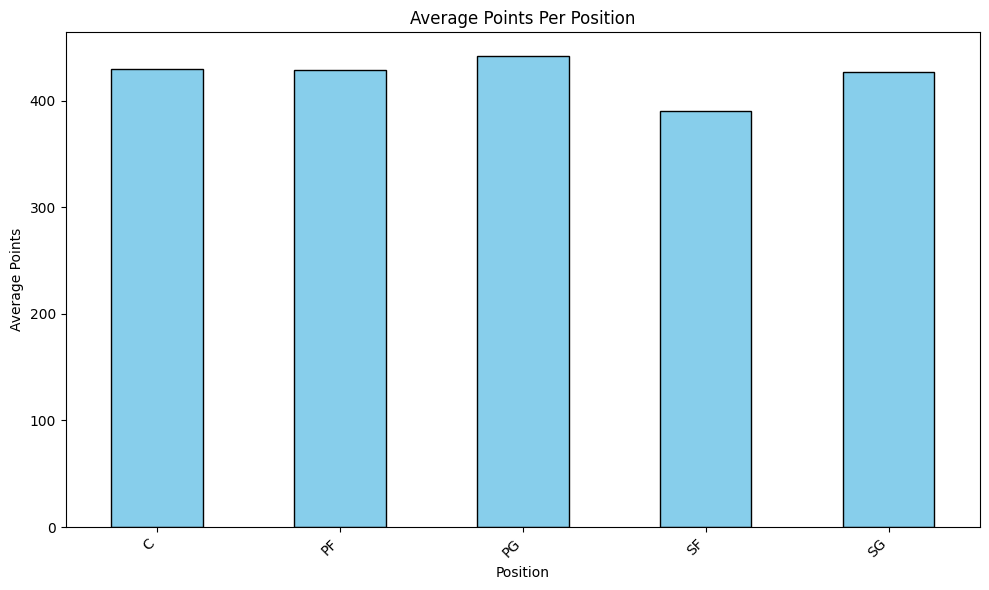

In [146]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
average_pts_per_position.plot(kind='bar', align='center', color='skyblue', edgecolor='black')
plt.title('Average Points Per Position')
plt.xlabel('Position')
plt.ylabel('Average Points')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [147]:
for col in ['Fg%', 'Fg3%', 'Fg2%', 'Ft%']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

average_percentages_per_position = df.groupby('Pos')[['Fg3%', 'Fg2%', 'Ft%']].mean().dropna()
display(average_percentages_per_position[1:])

,Fg3%,Fg2%,Ft%
Pos,,,
C,0.254871,0.589805,0.691730
PF,0.324472,0.540646,0.714029
PG,0.335156,0.475867,0.800229
SF,0.325344,0.515000,0.758786
SG,0.322065,0.492101,0.774822


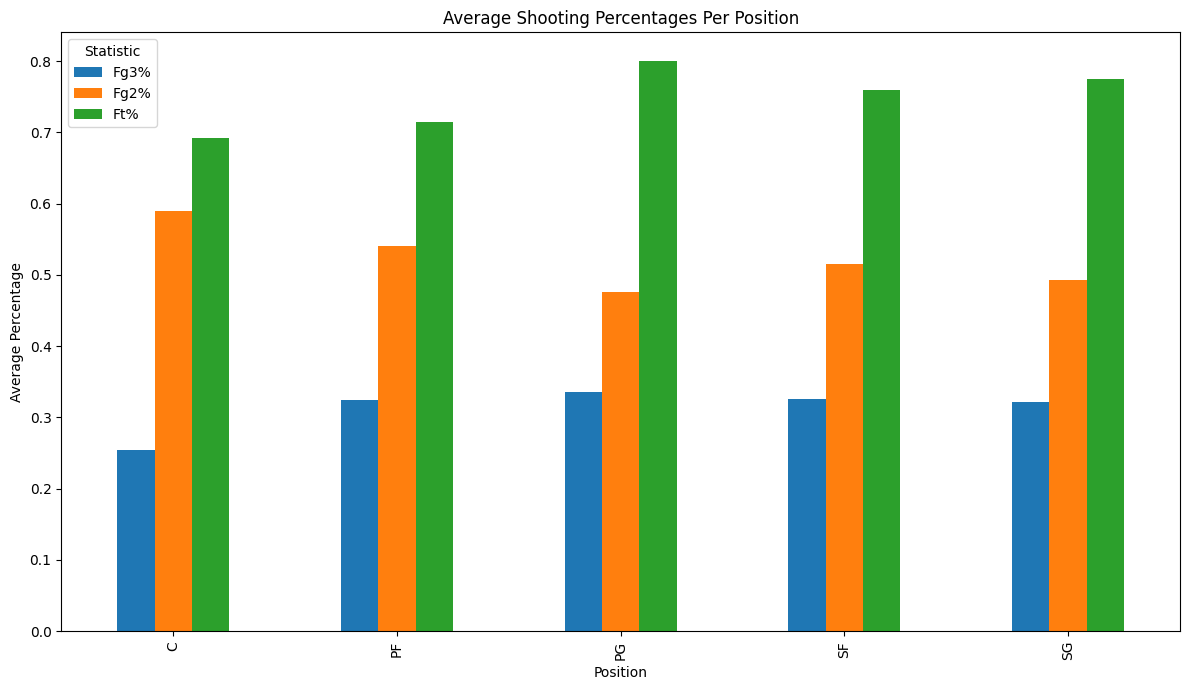

In [148]:
import matplotlib.pyplot as plt
average_percentages_per_position[1:].plot(kind='bar', figsize=(12, 7))
plt.title('Average Shooting Percentages Per Position')
plt.xlabel('Position')
plt.ylabel('Average Percentage')
plt.legend(title='Statistic')
plt.tight_layout()
plt.show()

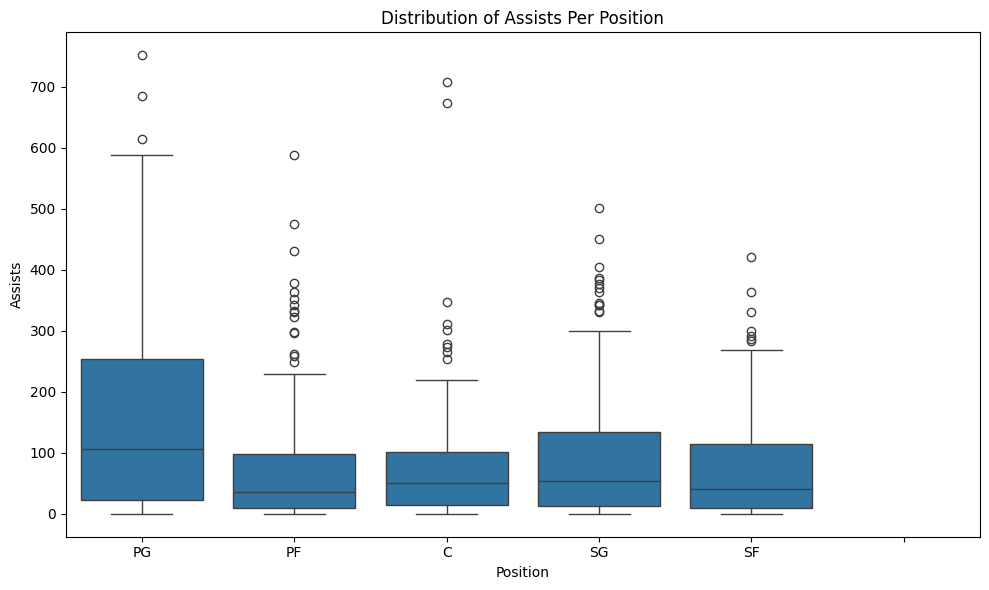

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Pos', y='Ast', vert=True, data=df)
plt.title('Distribution of Assists Per Position')
plt.xlabel('Position')
plt.ylabel('Assists')
plt.tight_layout()
plt.show()

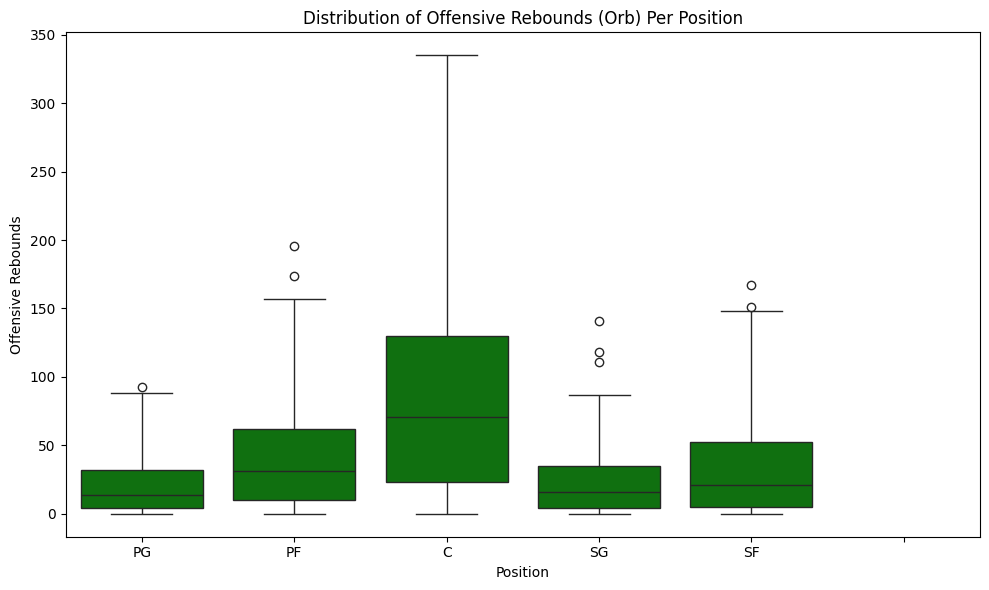

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pos', y='Orb', whis=2.0, data=df, color='green')
plt.title('Distribution of Offensive Rebounds (Orb) Per Position')
plt.xlabel('Position')
plt.ylabel('Offensive Rebounds')
plt.tight_layout()
plt.show()

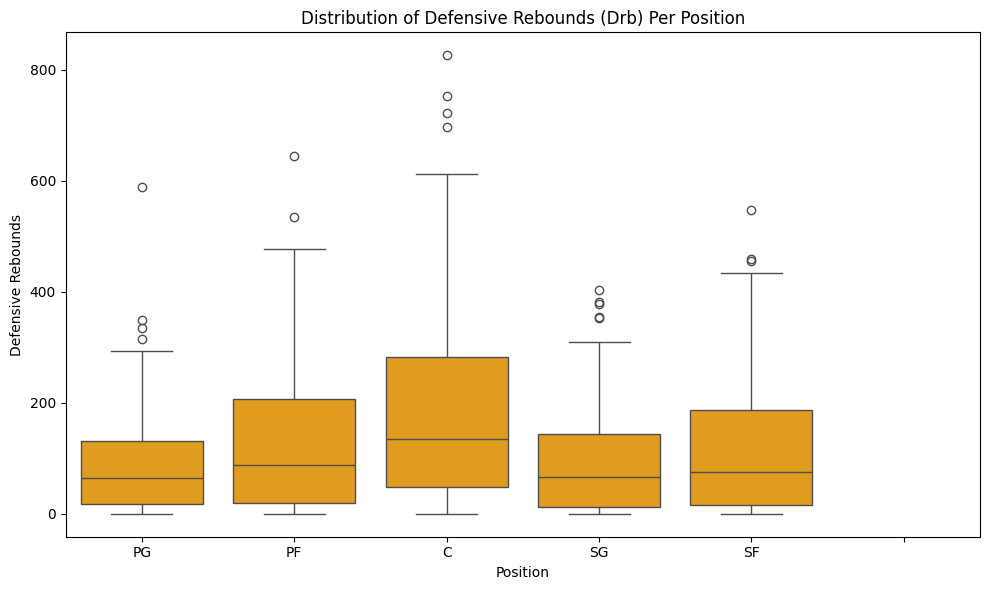

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pos', y='Drb', whis=1.5, data=df,color='Orange')
plt.title('Distribution of Defensive Rebounds (Drb) Per Position')
plt.xlabel('Position')
plt.ylabel('Defensive Rebounds')
plt.tight_layout()
plt.show()

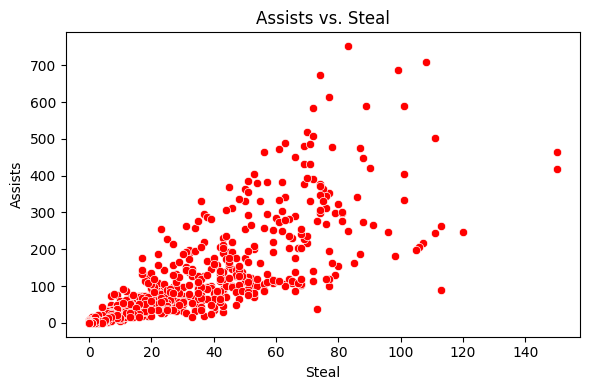

In [152]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Stl', y='Ast', data=df, color='red')
plt.title("Assists vs. Steal")
plt.xlabel("Steal")
plt.ylabel("Assists")
plt.tight_layout()
plt.show()

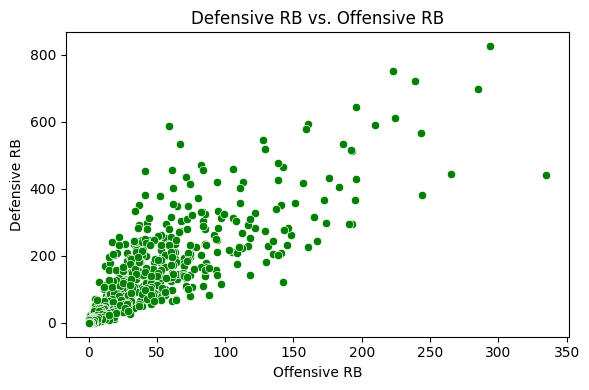

In [153]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Orb', y='Drb', data=df, color='green')
plt.title("Defensive RB vs. Offensive RB")
plt.xlabel("Offensive RB")
plt.ylabel("Defensive RB")
plt.tight_layout()
plt.show()

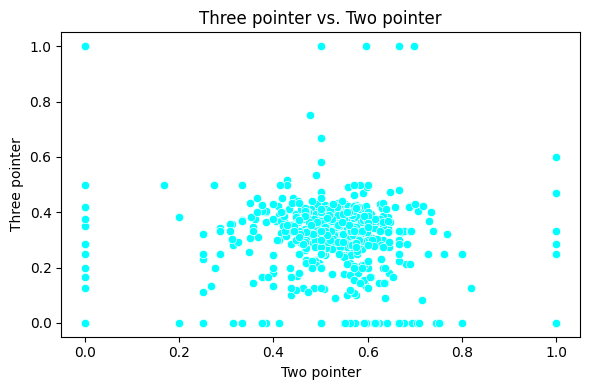

In [166]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Fg2%', y='Fg3%', data=df, color='cyan')
plt.title("Three pointer vs. Two pointer")
plt.xlabel("Two pointer")
plt.ylabel("Three pointer")
plt.tight_layout()
plt.show()

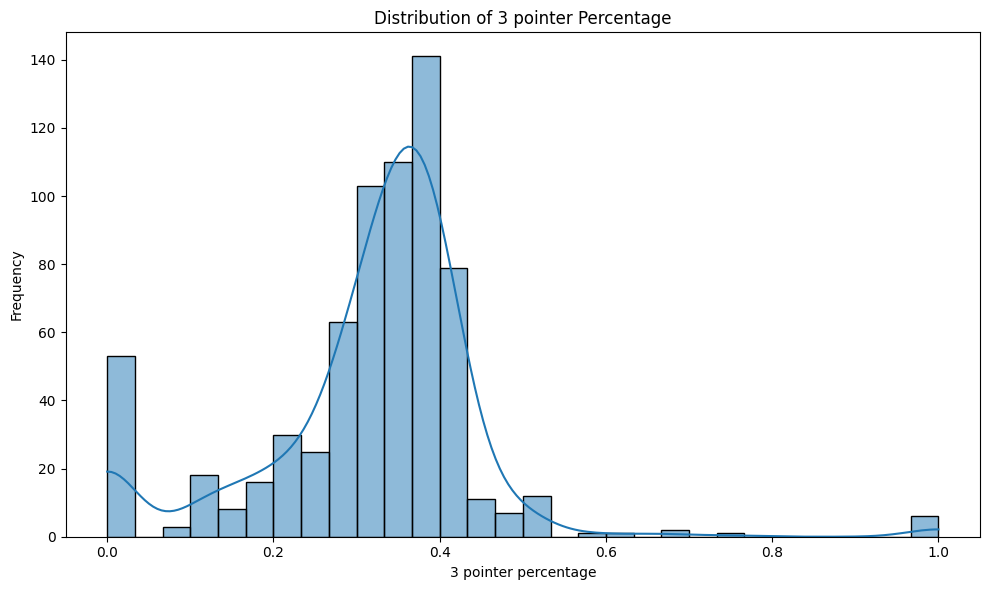

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df['Fg3%'], kde=True, bins=30)
plt.title('Distribution of 3 pointer Percentage')
plt.xlabel('3 pointer percentage')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

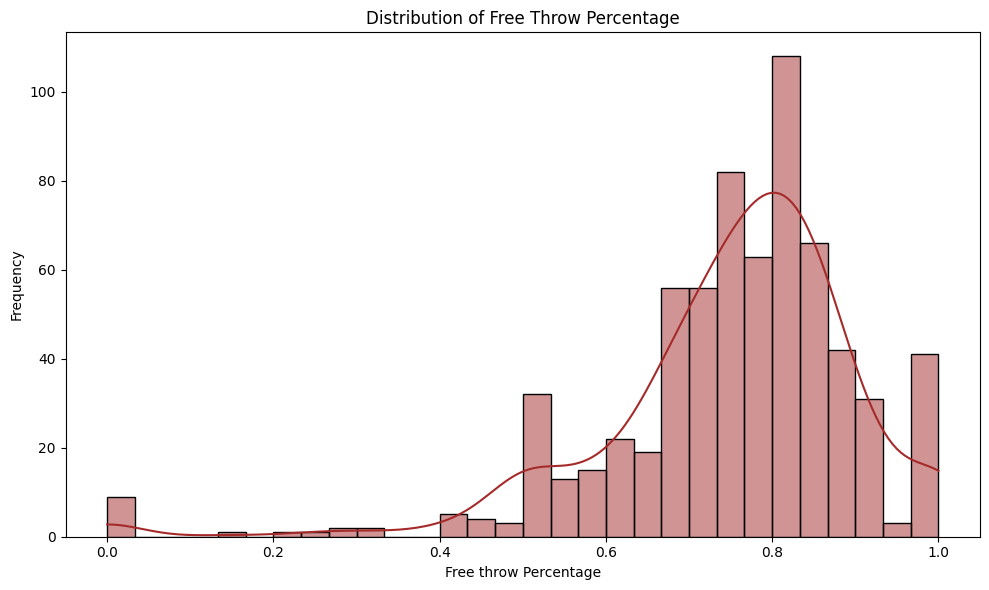

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df['Ft%'], kde=True, bins=30, color='brown')
plt.title('Distribution of Free Throw Percentage')
plt.xlabel('Free throw Percentage')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

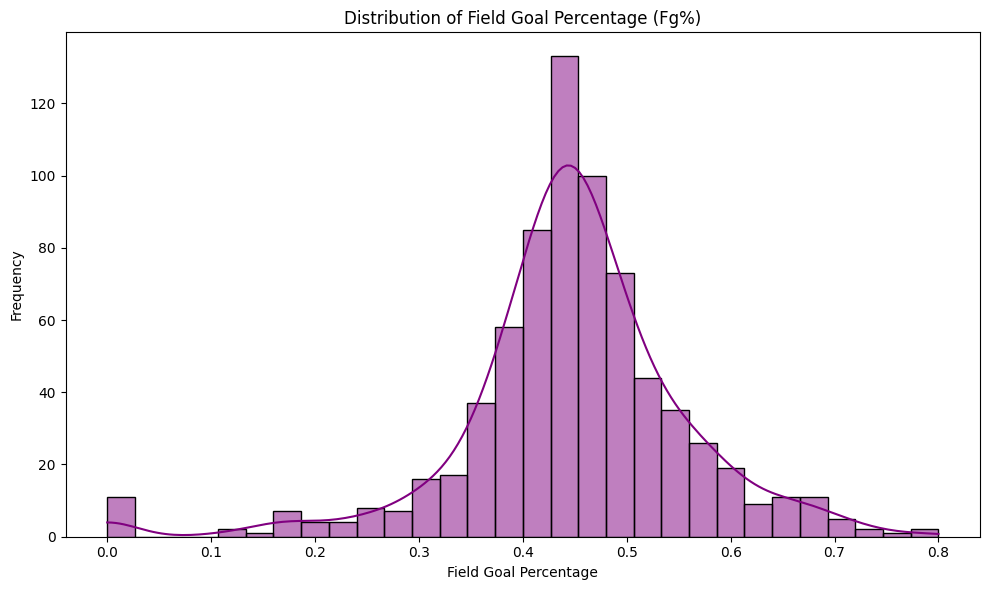

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df['Fg%'], kde=True, bins=30, color='purple')
plt.title('Distribution of Field Goal Percentage (Fg%)')
plt.xlabel('Field Goal Percentage')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

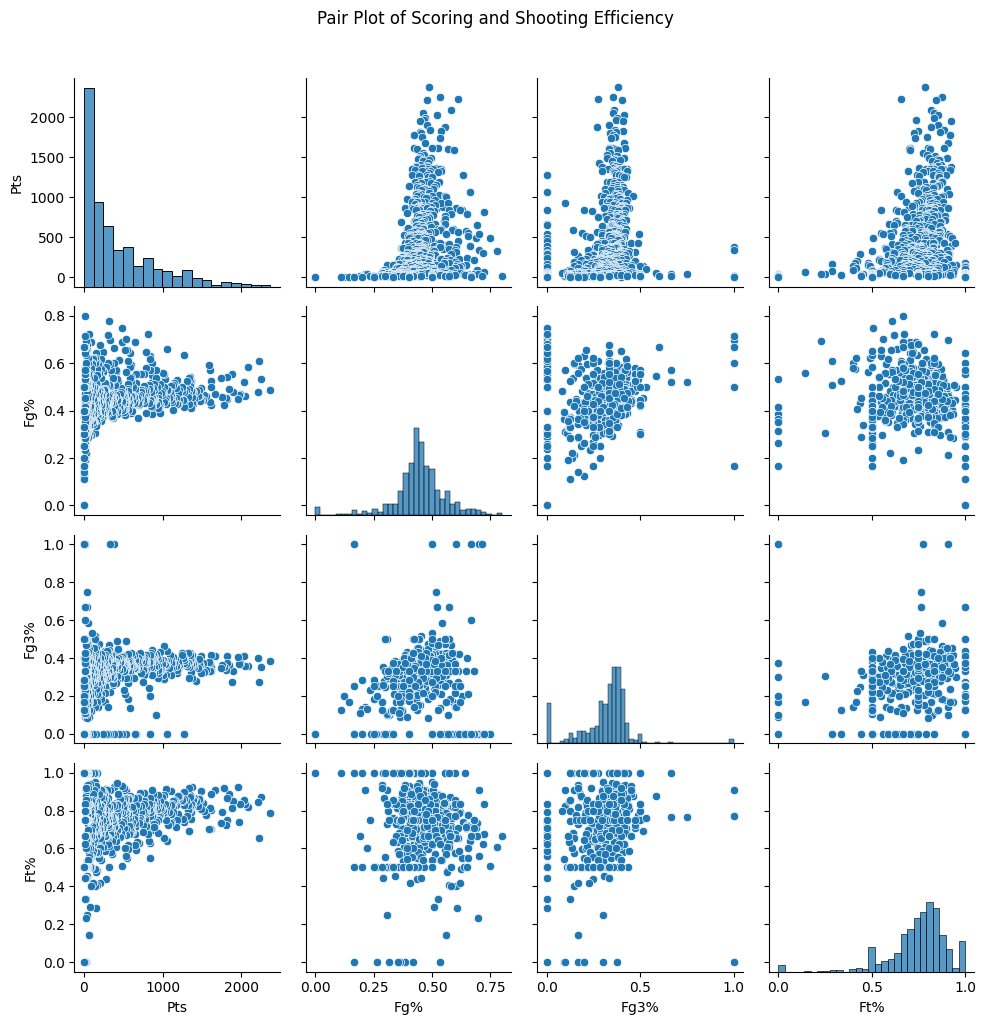

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt
cols_to_plot = ['Pts', 'Fg%', 'Fg3%', 'Ft%']
sns.pairplot(df[cols_to_plot])
plt.suptitle('Pair Plot of Scoring and Shooting Efficiency', y=1.02)
plt.tight_layout()
plt.show()

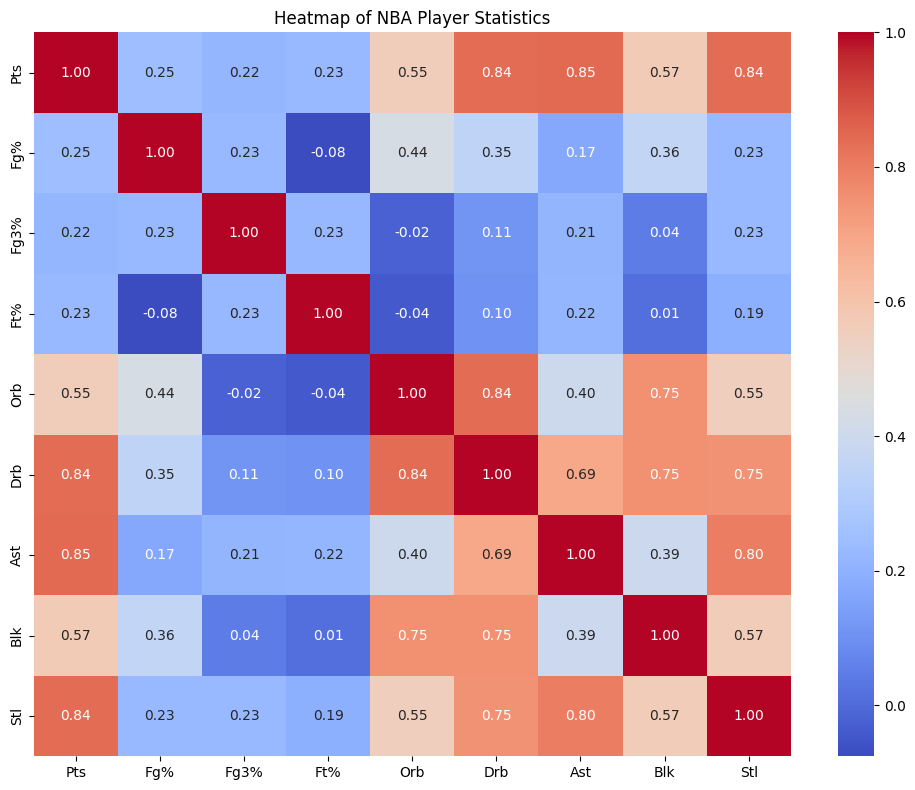

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt
numerical_cols = ['Pts', 'Fg%', 'Fg3%', 'Ft%', 'Orb', 'Drb', 'Ast', 'Blk', 'Stl']
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of NBA Player Statistics')
plt.tight_layout()
plt.show()